In [156]:
from pathlib import Path
import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.dpi"] = 300

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _resolve_summary_path(result_folder: str | Path) -> Path:
    """Find one ProtSpace eval summary.tsv from a result folder or direct path."""
    path = Path(result_folder)
    if path.is_file():
        return path

    candidates = [
        path / "summary.tsv",
        path / "eval" / "prott5" / "summary.tsv",
        path / "eval" / "prot_t5" / "summary.tsv",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    found = sorted(path.rglob("summary.tsv"))
    if len(found) == 1:
        return found[0]
    if not found:
        raise FileNotFoundError(f"No summary.tsv found under {path}")
    raise ValueError(
        "Multiple summary.tsv files found. Pass one exact summary path instead:\n"
        + "\n".join(str(item) for item in found)
    )


def _read_summary(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep="\t", comment="#")


def _wide_label_summary(label_summary: pd.DataFrame) -> pd.DataFrame | None:
    """Convert older per-label summary.tsv files to wide metric:label columns."""
    if "space" not in label_summary.columns or "label" not in label_summary.columns:
        return None
    labels = label_summary["label"].dropna().astype(str).unique().tolist()
    if len(labels) != 1:
        return None
    label = labels[0]
    metadata_columns = {
        "space",
        "type",
        "label",
        "n_samples",
        "k_values",
        "classifier_folds",
        "regression_folds",
        "knn_k",
        "robustness_runs",
    }
    metric_columns = [
        column for column in label_summary.columns if column not in metadata_columns
    ]
    if not metric_columns:
        return None
    wide = label_summary[["space", *metric_columns]].copy()
    wide = wide.rename(columns={column: f"{column}:{label}" for column in metric_columns})
    return wide


def _load_summary_table(result_folder: str | Path) -> tuple[Path, pd.DataFrame]:
    """Load modern wide summaries or merge older per-label summary folders."""
    summary_path = _resolve_summary_path(result_folder)
    summary = _read_summary(summary_path)
    if any(":" in column for column in summary.columns):
        return summary_path, summary

    combined = summary.copy()
    label_summaries = sorted(summary_path.parent.glob("*/summary.tsv"))
    for label_summary_path in label_summaries:
        label_summary = _read_summary(label_summary_path)
        wide = _wide_label_summary(label_summary)
        if wide is not None:
            combined = combined.merge(wide, on="space", how="outer")
    return summary_path, combined


def _split_metric_label(column: str) -> tuple[str, str | None]:
    if ":" not in column:
        return column, None
    metric, label = column.split(":", 1)
    return metric, label


def _is_std_metric(metric: str) -> bool:
    return metric.endswith("_std") or "_mean_std" in metric


def _std_column_for(mean_column: str, columns: set[str]) -> str | None:
    metric, label = _split_metric_label(mean_column)
    std_metric = f"{metric}_std"
    std_column = f"{std_metric}:{label}" if label is not None else std_metric
    return std_column if std_column in columns else None


def _label_matches(label: str, label_filter: str | list[str] | tuple[str, ...] | None) -> bool:
    if label_filter is None or label_filter == "" or label_filter == []:
        return True
    if isinstance(label_filter, str):
        filters = [label_filter]
    else:
        filters = list(label_filter)
    return any(str(item).lower() in label.lower() for item in filters if str(item))


def _row_exclusion_mask(spaces: pd.Series, row_filter: str | list[str] | tuple[str, ...] | None) -> pd.Series:
    """True for rows that should be excluded by one or more substring filters."""
    if row_filter is None or row_filter == "" or row_filter == []:
        return pd.Series(False, index=spaces.index)
    filters = [row_filter] if isinstance(row_filter, str) else list(row_filter)
    mask = pd.Series(False, index=spaces.index)
    space_text = spaces.astype(str)
    for item in filters:
        text = str(item)
        if text:
            mask |= space_text.str.contains(text, case=False, regex=False)
    return mask


def _metric_pairs(columns: list[str], *, include_concordex: bool) -> list[tuple[str, str | None]]:
    """Return (mean_column, std_column) pairs in display order."""
    column_set = set(columns)
    pairs = []
    for column in columns:
        if column in {"space", "type"}:
            continue
        metric, _label = _split_metric_label(column)
        if _is_std_metric(metric):
            continue
        if not include_concordex and metric.startswith("concordex"):
            continue
        pairs.append((column, _std_column_for(column, column_set)))
    return pairs


def _display_metric_name(column: str) -> str:
    metric, _label = _split_metric_label(column)
    return metric


def _normalized_space_name(space: str) -> str:
    return str(space).strip().lower().replace(" ", "")


def _is_removed_space(space: str) -> bool:
    normalized = _normalized_space_name(space)
    return normalized.startswith(("pca10", "pca(10)", "pca50", "pca(50)"))


def _display_space_name(space: str) -> str:
    text = str(space).strip()
    normalized = _normalized_space_name(text)
    if normalized.startswith("original"):
        return "Original1024"
    return text


def _space_order_key(space: str) -> tuple[int, int, str]:
    """Sort rows as Original1024, PCA2, rhoPCA, UMAP2, rhoPCA+UMAP."""
    normalized = _normalized_space_name(space)
    has_rhopca = "rhopca" in normalized
    has_umap = "umap" in normalized
    if normalized.startswith("original"):
        return (0, 0, normalized)
    if normalized.startswith(("pca2", "pca(2)")):
        return (1, 0, normalized)
    if has_rhopca and has_umap:
        return (4, 0, normalized)
    if has_rhopca:
        return (2, 0, normalized)
    if normalized.startswith(("umap2", "umap(2)")):
        return (3, 0, normalized)
    return (99, 0, normalized)


def _ordered_panel_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.loc[~frame["space"].astype(str).map(_is_removed_space)].copy()
    order = sorted(
        range(len(frame)),
        key=lambda index: _space_order_key(str(frame.iloc[index]["space"])),
    )
    return frame.iloc[order].reset_index(drop=True)


def _shared_ordered_spaces(panels: list[tuple[str, pd.DataFrame]]) -> list[str]:
    spaces: list[str] = []
    seen: set[str] = set()
    for _title, frame in panels:
        for space in _ordered_panel_frame(frame)["space"].astype(str):
            if space not in seen:
                spaces.append(space)
                seen.add(space)
    return sorted(spaces, key=_space_order_key)


def _align_panel_to_spaces(frame: pd.DataFrame, spaces: list[str]) -> pd.DataFrame:
    frame = _ordered_panel_frame(frame).copy()
    frame["__space_key"] = frame["space"].astype(str)
    frame = frame.drop_duplicates("__space_key", keep="first").drop(columns=["space"])
    aligned = pd.DataFrame({"space": spaces}).merge(
        frame,
        left_on="space",
        right_on="__space_key",
        how="left",
    )
    return aligned.drop(columns=["__space_key"])


def _panel_metric_count(frame: pd.DataFrame, include_concordex: bool) -> int:
    metric_pairs = _metric_pairs(list(frame.columns), include_concordex=include_concordex)
    metric_pairs = [
        (mean_col, std_col)
        for mean_col, std_col in metric_pairs
        if pd.to_numeric(frame[mean_col], errors="coerce").notna().any()
    ]
    return max(1, len(metric_pairs))


def _space_section(space: str) -> str:
    normalized = _normalized_space_name(space)
    has_rhopca = "rhopca" in normalized
    has_umap = "umap" in normalized
    if normalized.startswith("original"):
        return "Original1024"
    if normalized.startswith(("pca2", "pca(2)")):
        return "PCA2"
    if has_rhopca and has_umap:
        return "rhoPCA + UMAP"
    if has_rhopca:
        return "rhoPCA"
    if normalized.startswith(("umap2", "umap(2)")):
        return "UMAP2"
    return "Other"


def _section_ranges(spaces: pd.Index) -> list[tuple[str, int, int]]:
    sections = [_space_section(space) for space in spaces]
    if not sections:
        return []
    ranges = []
    start = 0
    current = sections[0]
    for index, section in enumerate(sections[1:], start=1):
        if section != current:
            ranges.append((current, start, index - 1))
            start = index
            current = section
    ranges.append((current, start, len(sections) - 1))
    return ranges


def _draw_metric_heatmap(
    ax,
    frame: pd.DataFrame,
    *,
    title: str,
    include_concordex: bool,
    show_std: bool,
    vmin: float = -1,
    vmax: float = 1,
    cmap: str = "seismic",
):
    frame = _ordered_panel_frame(frame)
    metric_pairs = _metric_pairs(list(frame.columns), include_concordex=include_concordex)
    metric_pairs = [
        (mean_col, std_col)
        for mean_col, std_col in metric_pairs
        if pd.to_numeric(frame[mean_col], errors="coerce").notna().any()
    ]
    if not metric_pairs:
        ax.axis("off")
        ax.set_title(f"{title}\n(no plottable metrics)")
        return None

    means = frame[[mean_col for mean_col, _ in metric_pairs]].apply(pd.to_numeric, errors="coerce")
    means.index = frame["space"].astype(str).map(_display_space_name)
    means.columns = [_display_metric_name(mean_col) for mean_col, _ in metric_pairs]

    annotations = means.copy().astype(object)
    for display_col, (mean_col, std_col) in zip(means.columns, metric_pairs, strict=False):
        mean_values = pd.to_numeric(frame[mean_col], errors="coerce")
        if show_std and std_col is not None:
            std_values = pd.to_numeric(frame[std_col], errors="coerce")
            annotations[display_col] = [
                "" if pd.isna(mean) else f"{mean:.3f}\n±{std:.3f}" if pd.notna(std) else f"{mean:.3f}"
                for mean, std in zip(mean_values, std_values, strict=False)
            ]
        else:
            annotations[display_col] = [
                "" if pd.isna(mean) else f"{mean:.3f}" for mean in mean_values
            ]

    values = means.to_numpy(dtype=float)
    x_edges = np.arange(means.shape[1] + 1)
    y_edges = np.arange(means.shape[0] + 1)
    image = ax.pcolormesh(
        x_edges,
        y_edges,
        values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="flat",
        edgecolors="black",
        linewidth=0.55,
        antialiased=False,
        snap=True,
    )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=4)
    ax.set_xticks(np.arange(means.shape[1]) + 0.5)
    ax.set_xticklabels(means.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(means.shape[0]) + 0.5)
    ax.set_yticklabels(means.index)

    x_min, x_max = 0, means.shape[1]
    y_min, y_max = 0, means.shape[0]
    section_ranges = _section_ranges(means.index)
    for section, start, end in section_ranges:
        if start > 0:
            ax.axhline(start, color="black", linewidth=2.6, zorder=4)

    # Hide only the outer pcolormesh edge; internal cell edges remain black and aligned.
    ax.hlines([y_min, y_max], x_min, x_max, colors="white", linewidth=1.2, zorder=4.5, clip_on=False)
    ax.vlines([x_min, x_max], y_min, y_max, colors="white", linewidth=1.2, zorder=4.5, clip_on=False)

    for row_index in range(means.shape[0]):
        for col_index in range(means.shape[1]):
            text = annotations.iat[row_index, col_index]
            if text:
                value = means.iat[row_index, col_index]
                color = "white" if pd.notna(value) and abs(value) > 0.55 else "black"
                ax.text(col_index + 0.5, row_index + 0.5, text, ha="center", va="center", fontsize=9, fontweight="bold", color=color, zorder=5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)
    ax.set_aspect("auto")
    ax.margins(0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return image


def plot_protspace_summary(
    result_folder: str | Path,
    *,
    include_tsne: bool = True,
    row_filter: str | list[str] | tuple[str, ...] | None = None,
    include_unsupervised: bool = True,
    supervised_label_filter: str | list[str] | tuple[str, ...] | None = None,
    include_concordex: bool = False,
    title: str | None = None,
    subplot_titles: list[str] | tuple[str, ...] | None = None,
    max_subplots: int | None = 2,
    show_std: bool = True,
    save: bool = False,
):
    """Plot one ProtSpace summary.tsv as one figure with multiple subplots.

    The figure contains the unsupervised metrics first, if enabled, followed by
    one supervised subplot per selected label. All subplots use a fixed colour
    scale from -1 to 1.

    Parameters
    ----------
    result_folder:
        A ProtSpace result folder, eval folder, or exact summary.tsv path.
    include_tsne:
        If False, remove rows whose space contains t-SNE/tsne.
    row_filter:
        Optional case-insensitive substring or list of substrings. Rows containing any of them are excluded.
    include_unsupervised:
        If False, only supervised subplots are shown.
    supervised_label_filter:
        Optional label substring or list of substrings. Empty/None means all labels.
    include_concordex:
        If False, hide concordex columns from supervised subplots.
    title:
        Optional main figure title. If None, no main title is drawn.
    subplot_titles:
        Optional custom subplot titles. Must have exactly one title per subplot.
    max_subplots:
        Maximum number of subplots in the figure. The default, 2, keeps the
        geometry stable and avoids subplot-dependent heatmap scaling artifacts.
        Set to None to plot every available panel.
    show_std:
        If True, annotate cells as mean ± std when std columns exist.
    save:
        If True, save one PNG beside the summary.tsv.
    """
    summary_path, summary = _load_summary_table(result_folder)
    if "space" not in summary.columns:
        raise ValueError(f"{summary_path} has no 'space' column")

    filtered = summary.copy()
    if not include_tsne:
        filtered = filtered[~filtered["space"].astype(str).str.contains("t-sne|tsne", case=False, regex=True)]
    if row_filter:
        filtered = filtered[~_row_exclusion_mask(filtered["space"], row_filter)]
    if filtered.empty:
        raise ValueError("No rows remain after filtering")

    panels: list[tuple[str, pd.DataFrame]] = []
    if include_unsupervised:
        unsupervised_cols = [
            column
            for column in [
                "space",
                "recall_mean",
                "recall_mean_std",
                "trust_mean",
                "trust_mean_std",
                "cont_mean",
                "cont_mean_std",
            ]
            if column in filtered.columns
        ]
        if len(unsupervised_cols) > 1:
            panels.append(("Unsupervised", filtered[unsupervised_cols]))

    supervised_labels = sorted(
        {
            label
            for column in filtered.columns
            for metric, label in [_split_metric_label(column)]
            if label is not None and not _is_std_metric(metric)
        }
    )
    supervised_labels = [
        label for label in supervised_labels if _label_matches(label, supervised_label_filter)
    ]
    for label in supervised_labels:
        label_cols = [
            column
            for column in filtered.columns
            if column == "space" or column.endswith(f":{label}")
        ]
        if len(label_cols) > 1:
            label_panel = filtered[label_cols].copy()
            metric_cols = [column for column in label_cols if column != "space"]
            has_metric = label_panel[metric_cols].apply(pd.to_numeric, errors="coerce").notna().any(axis=1)
            label_panel = label_panel.loc[has_metric]
            if not label_panel.empty:
                panels.append((f"Supervised: {label}", label_panel))

    if not panels:
        raise ValueError("No panels to plot after applying filters")
    total_panel_count = len(panels)
    if max_subplots is not None:
        if max_subplots < 1:
            raise ValueError("max_subplots must be at least 1 or None")
        panels = panels[:max_subplots]

    shared_spaces = _shared_ordered_spaces(panels)
    panels = [
        (panel_title, _align_panel_to_spaces(panel_frame, shared_spaces))
        for panel_title, panel_frame in panels
    ]

    if subplot_titles is not None and len(subplot_titles) < len(panels):
        raise ValueError(
            f"subplot_titles must have at least {len(panels)} entries, got {len(subplot_titles)}"
        )
    panel_titles = list(subplot_titles) if subplot_titles is not None else [
        panel_title for panel_title, _panel_frame in panels
    ]
    panel_titles = panel_titles[:len(panels)]

    n_panels = len(panels)
    n_cols = n_panels
    metric_counts = [
        _panel_metric_count(panel_frame, include_concordex=include_concordex)
        for _title, panel_frame in panels
    ]
    fig_width = max(4.20 * n_cols, 1.18 * sum(metric_counts) + 2.52)
    fig_height = max(4.0, 0.38 * len(shared_spaces) + 2.4)
    fig, axes = plt.subplots(
        1,
        n_cols,
        figsize=(fig_width, fig_height),
        squeeze=False,
        sharey=False,
        gridspec_kw={"width_ratios": metric_counts, "wspace": 0.18},
    )
    axes = axes.ravel()

    last_image = None
    for panel_index, (ax, (_default_title, panel_frame), panel_title) in enumerate(
        zip(axes, panels, panel_titles, strict=False)
    ):
        image = _draw_metric_heatmap(
            ax,
            panel_frame,
            title=panel_title,
            include_concordex=include_concordex,
            show_std=show_std,
            vmin=-1,
            vmax=1,
            cmap="seismic",
        )
        if image is not None:
            last_image = image
        if panel_index != 0:
            ax.tick_params(axis="y", labelleft=False, length=0)
        else:
            ax.tick_params(axis="y", labelleft=True, length=0)

    for ax in axes[n_panels:]:
        ax.axis("off")

    if title:
        fig.suptitle(title, y=0.985, fontsize=15, fontweight="bold")
    # Reserve a fixed strip on the right for the shared colour bar so it never
    # overlaps the rightmost subplot.
    fig.tight_layout(rect=[0.12, 0.0, 0.89, 0.985 if title else 0.98])
    if last_image is not None:
        cbar_ax = fig.add_axes([0.925, 0.14, 0.018, 0.72])
        fig.colorbar(last_image, cax=cbar_ax)
    if save:
        suffix = []
        suffix.append("with_tsne" if include_tsne else "no_tsne")
        suffix.append("with_unsup" if include_unsupervised else "no_unsup")
        if row_filter:
            filter_text = row_filter if isinstance(row_filter, str) else "_".join(row_filter)
            suffix.append("exclude_" + "".join(ch if ch.isalnum() else "_" for ch in filter_text))
        if supervised_label_filter:
            filter_text = supervised_label_filter if isinstance(supervised_label_filter, str) else "_".join(supervised_label_filter)
            suffix.append("labelfilter_" + "".join(ch if ch.isalnum() else "_" for ch in filter_text))
        suffix.append("with_concordex" if include_concordex else "no_concordex")
        fig.savefig(summary_path.parent / f"summary_heatmap_{'_'.join(suffix)}.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Summary: {summary_path}")
    print(f"Rows plotted: {len(filtered)} / {len(summary)}")
    if total_panel_count > n_panels:
        print(f"Panels shown: {n_panels} / {total_panel_count} (max_subplots={max_subplots})")
    print("Panels:", ", ".join(title for title, _frame in panels))
    return filtered


/tmp/ipykernel_9230/2091407133.py:523: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.12, 0.0, 0.89, 0.985 if title else 0.98])


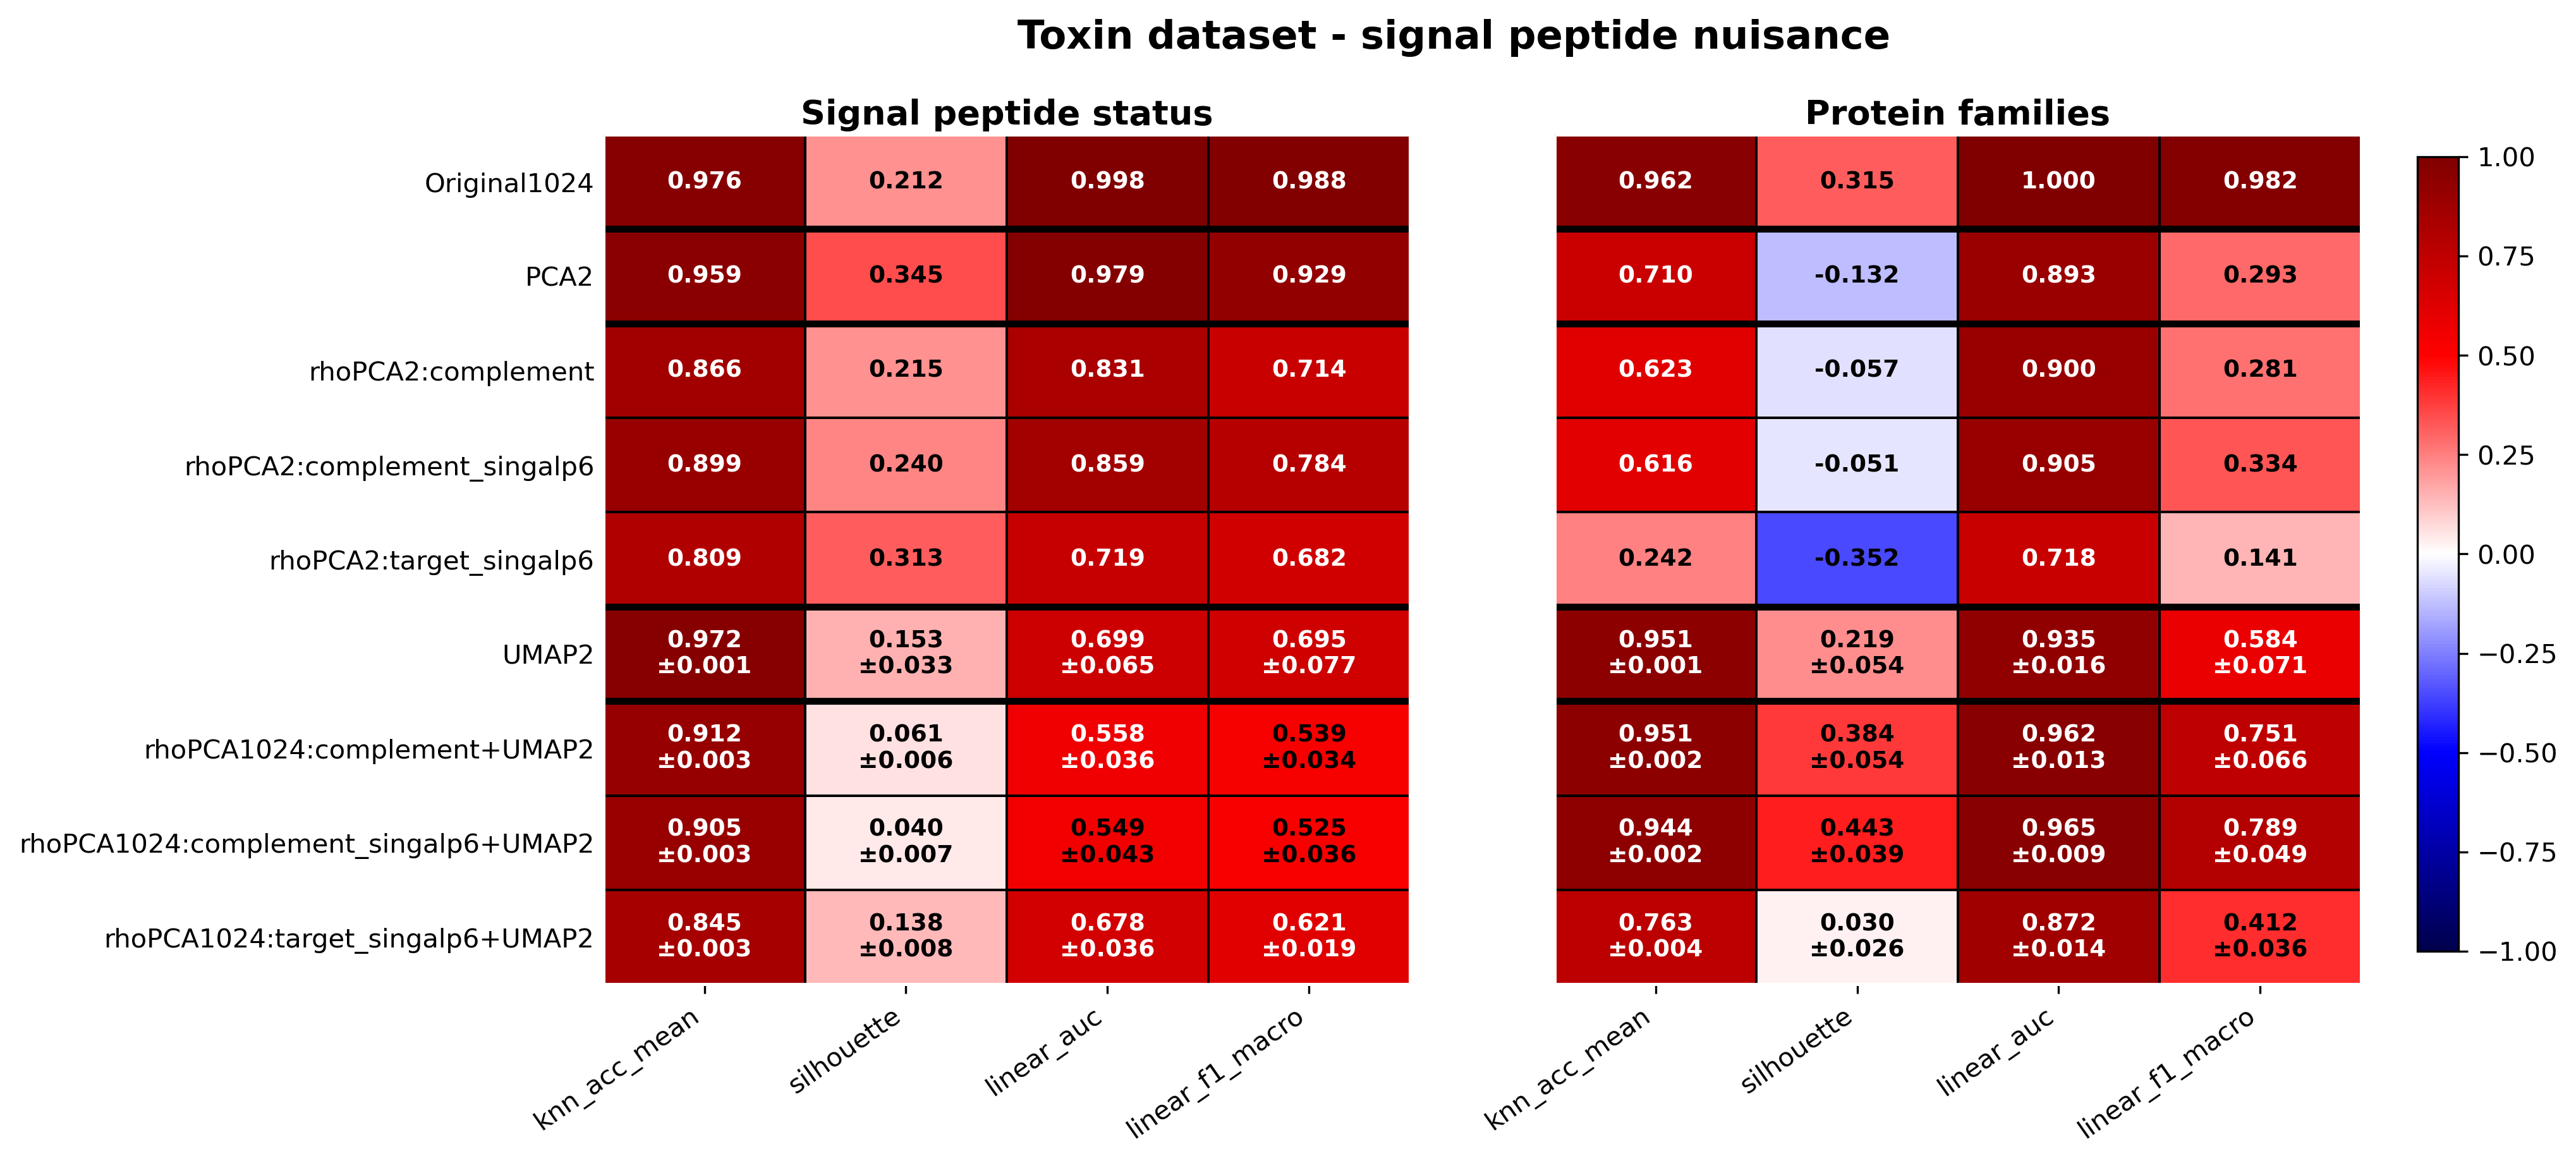

Summary: protspace_results/toxins_signal/eval/prott5/summary.tsv
Rows plotted: 11 / 21
Panels: Supervised: ft_signal_bin, Supervised: protein_families


,space,recall_mean,recall_mean_std,trust_mean,trust_mean_std,cont_mean,cont_mean_std,knn_acc_mean:protein_families,knn_acc_mean_std:protein_families,silhouette:protein_families,...,knn_acc_mean:ft_signal_bin,knn_acc_mean_std:ft_signal_bin,silhouette:ft_signal_bin,silhouette_std:ft_signal_bin,concordex:ft_signal_bin,concordex_std:ft_signal_bin,linear_auc:ft_signal_bin,linear_auc_std:ft_signal_bin,linear_f1_macro:ft_signal_bin,linear_f1_macro_std:ft_signal_bin
0,Original (1024),-,-,-,-,-,-,0.9621,-,0.3147,...,0.9758,-,0.2122,-,1.9174,-,0.9978,-,0.9884,-
1,PCA50,-,-,-,-,-,-,0.9626,-,0.2668,...,0.9766,-,0.1648,-,1.9157,-,0.9966,-,0.9818,-
2,PCA10,-,-,-,-,-,-,0.9351,-,0.2375,...,0.9772,-,0.2248,-,1.9215,-,0.9941,-,0.9702,-
3,PCA2,0.2039,-,0.9534,-,0.9674,-,0.7096,-,-0.1323,...,0.9587,-,0.3450,-,1.8589,-,0.9787,-,0.9293,-
4,rhoPCA2:complement,0.1438,-,0.9428,-,0.9562,-,0.6228,-,-0.0567,...,0.8657,-,0.2155,-,1.6091,-,0.8307,-,0.7140,-
5,rhoPCA2:complement_singalp6,0.1368,-,0.9418,-,0.9558,-,0.6156,-,-0.0511,...,0.8994,-,0.2399,-,1.6798,-,0.8590,-,0.7839,-
6,rhoPCA2:target_singalp6,0.0449,-,0.9246,-,0.9297,-,0.2424,-,-0.3516,...,0.8093,-,0.3131,-,1.4081,-,0.7189,-,0.6825,-
7,UMAP2,0.5244,0.0016,0.9885,0.0001,0.991,0.0002,0.9512,0.0014,0.2190,...,0.9721,0.0012,0.1530,0.0327,1.9061,0.0033,0.6988,0.0649,0.6948,0.0766
11,rhoPCA1024:complement+UMAP2,0.4622,0.002,0.9803,0.0002,0.9834,0.0002,0.9505,0.0018,0.3835,...,0.9117,0.003,0.0606,0.006,1.7294,0.0068,0.5576,0.0361,0.5390,0.0342
12,rhoPCA1024:complement_singalp6+UMAP2,0.4502,0.0015,0.9785,0.0001,0.9814,0.0002,0.9441,0.0019,0.4427,...,0.9050,0.0029,0.0399,0.007,1.7132,0.0054,0.5491,0.0426,0.5254,0.0364


In [157]:
# Example: one figure with unsupervised first, then one subplot per supervised label.
plot_protspace_summary(
    "protspace_results/toxins_signal",
    include_tsne=False,
    row_filter="64",
    include_unsupervised=False,
    supervised_label_filter=None,
    include_concordex=False,
    show_std=True,
    save=False,
    title="Toxin dataset - signal peptide nuisance",
    subplot_titles=["Signal peptide status", "Protein families"],
)



/tmp/ipykernel_9230/2091407133.py:523: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.12, 0.0, 0.89, 0.985 if title else 0.98])


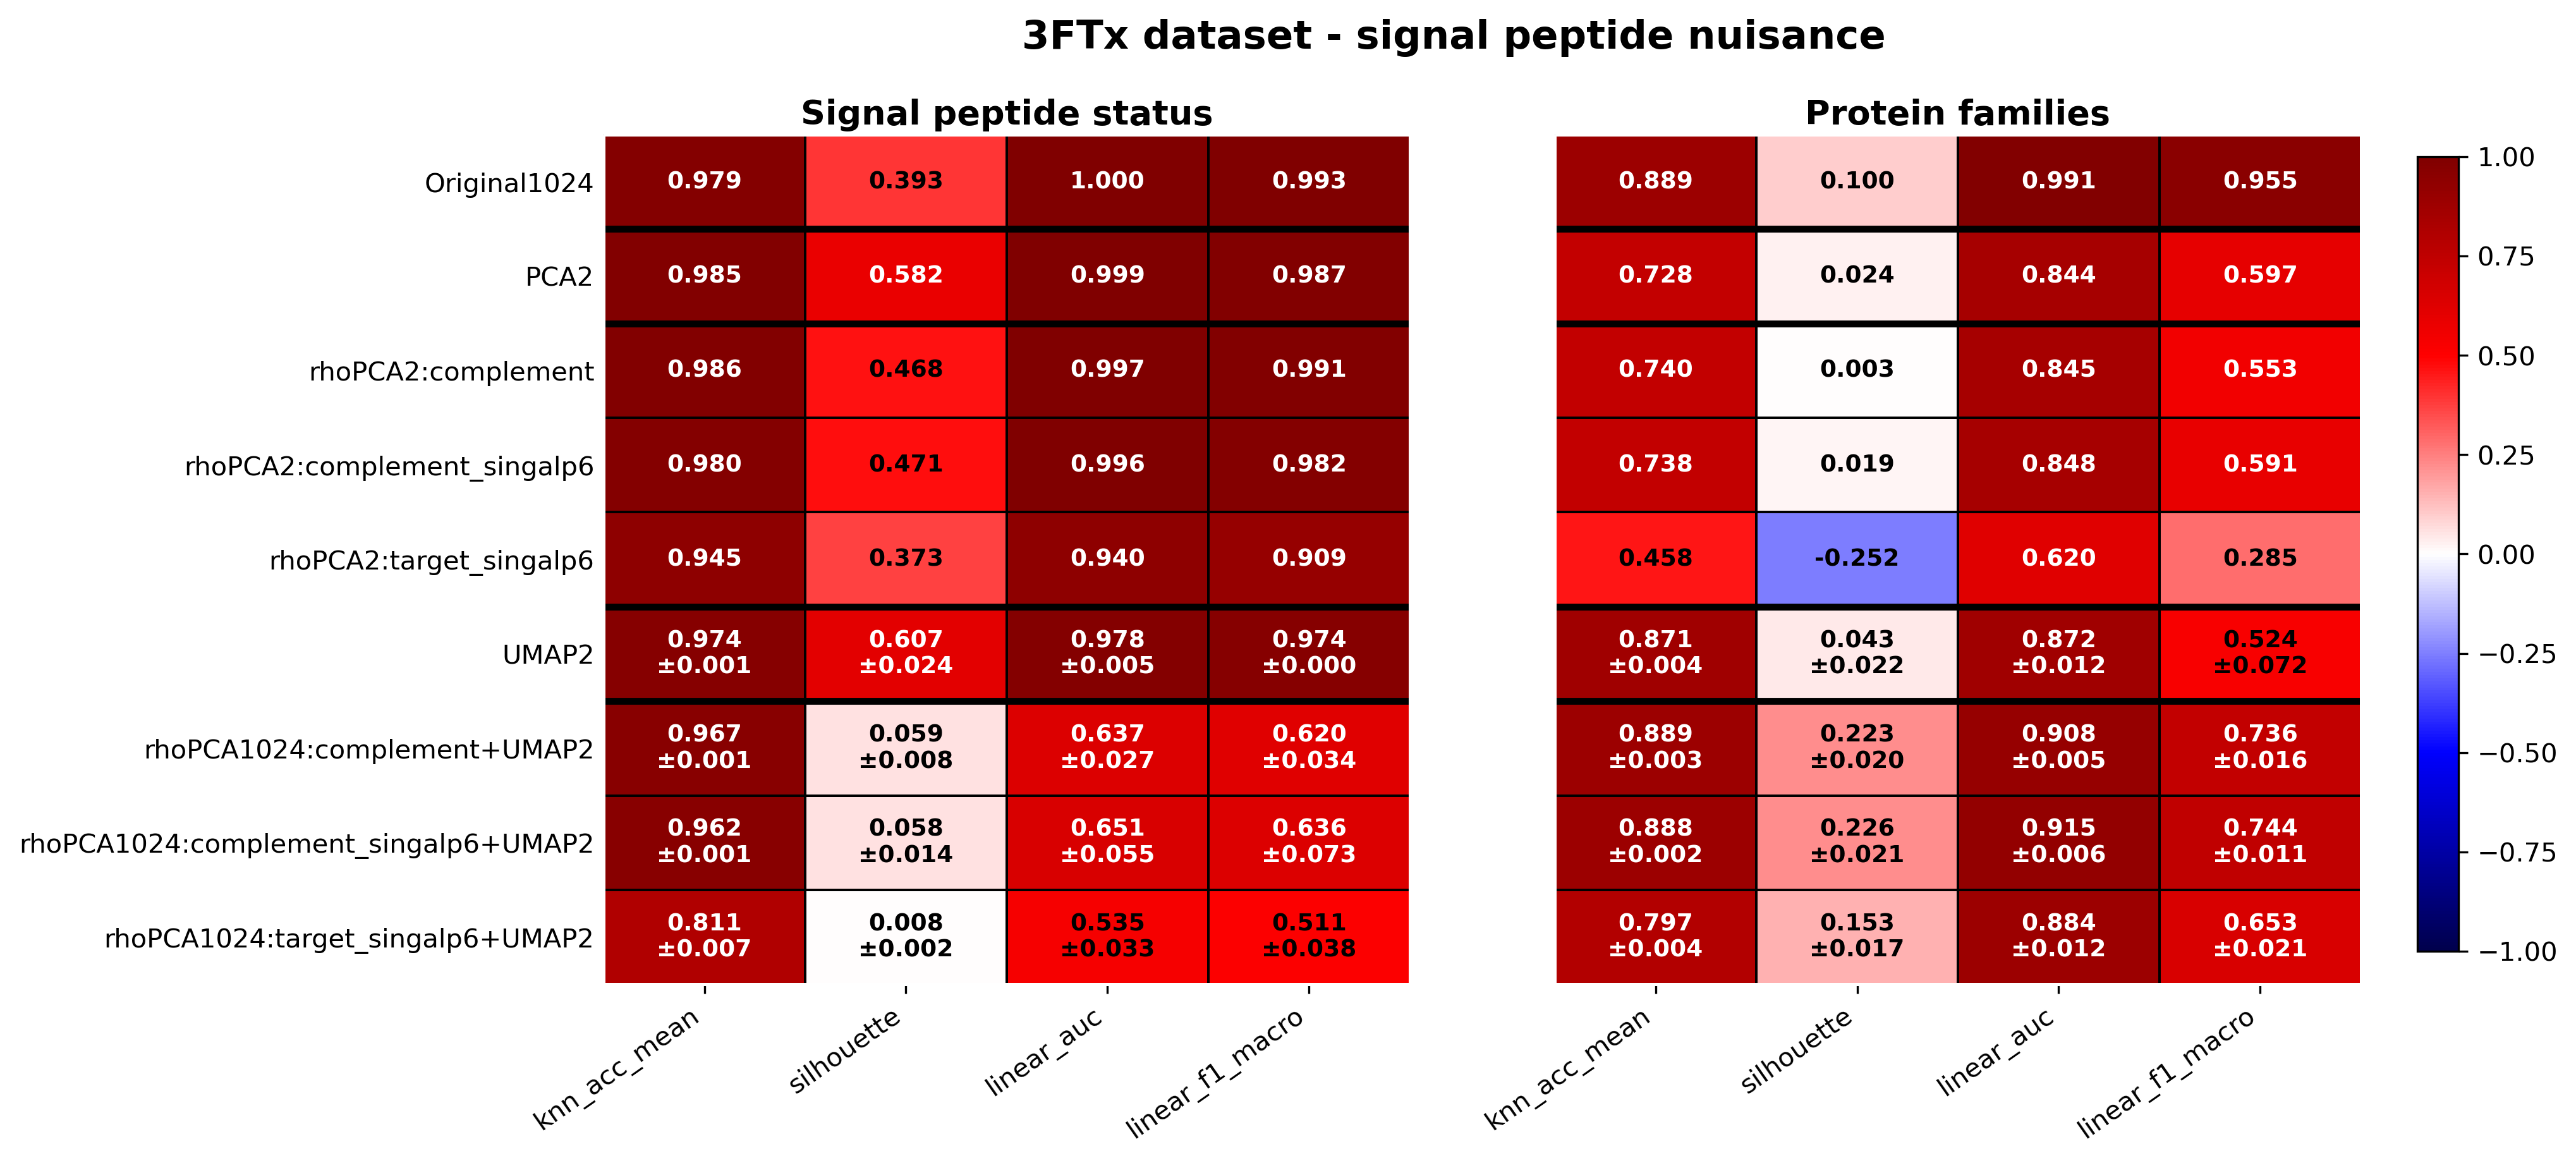

Summary: protspace_results/3FTx_signal/eval/prott5/summary.tsv
Rows plotted: 11 / 21
Panels: Supervised: has_full, Supervised: major_group


,space,recall_mean,recall_mean_std,trust_mean,trust_mean_std,cont_mean,cont_mean_std,knn_acc_mean:major_group,knn_acc_mean_std:major_group,silhouette:major_group,...,knn_acc_mean:has_full,knn_acc_mean_std:has_full,silhouette:has_full,silhouette_std:has_full,concordex:has_full,concordex_std:has_full,linear_auc:has_full,linear_auc_std:has_full,linear_f1_macro:has_full,linear_f1_macro_std:has_full
0,Original (1024),-,-,-,-,-,-,0.8886,-,0.1004,...,0.9786,-,0.3928,-,1.9554,-,0.9999,-,0.9929,-
1,PCA50,-,-,-,-,-,-,0.8942,-,0.0693,...,0.9787,-,0.2661,-,1.9532,-,0.9997,-,0.9915,-
2,PCA10,-,-,-,-,-,-,0.8848,-,0.0890,...,0.9804,-,0.3320,-,1.9550,-,0.9995,-,0.9887,-
3,PCA2,0.2462,-,0.8549,-,0.9057,-,0.7277,-,0.0240,...,0.9850,-,0.5818,-,1.9583,-,0.9991,-,0.9865,-
4,rhoPCA2:complement,0.2391,-,0.8492,-,0.9099,-,0.7403,-,0.0029,...,0.9863,-,0.4683,-,1.9664,-,0.9974,-,0.9908,-
5,rhoPCA2:complement_singalp6,0.2507,-,0.8487,-,0.9123,-,0.7375,-,0.0189,...,0.9802,-,0.4714,-,1.9509,-,0.9959,-,0.9823,-
6,rhoPCA2:target_singalp6,0.0821,-,0.7282,-,0.7632,-,0.4583,-,-0.2523,...,0.9449,-,0.3734,-,1.8306,-,0.9396,-,0.9095,-
7,UMAP2,0.5591,0.0026,0.9619,0.0005,0.9678,0.0005,0.8706,0.0037,0.0435,...,0.9742,0.0009,0.6067,0.0241,1.9171,0.0025,0.9780,0.005,0.9736,0.0003
11,rhoPCA1024:complement+UMAP2,0.5287,0.0024,0.9541,0.0008,0.9558,0.0006,0.8891,0.0027,0.2228,...,0.9669,0.0014,0.0592,0.0077,1.8956,0.0044,0.6366,0.0269,0.6199,0.0344
12,rhoPCA1024:complement_singalp6+UMAP2,0.5273,0.0023,0.9532,0.0006,0.9527,0.0005,0.8877,0.0021,0.2262,...,0.9624,0.0011,0.0576,0.0138,1.8867,0.0042,0.6514,0.0548,0.6362,0.0735


In [158]:
# Example: one figure with unsupervised first, then one subplot per supervised label.
plot_protspace_summary(
    "protspace_results/3FTx_signal",
    include_tsne=False,
    row_filter="64",
    include_unsupervised=False,
    supervised_label_filter=None,
    include_concordex=False,
    show_std=True,
    save=False,
    title="3FTx dataset - signal peptide nuisance",
    subplot_titles=["Signal peptide status", "Protein families"],
)


/tmp/ipykernel_9230/2091407133.py:523: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.12, 0.0, 0.89, 0.985 if title else 0.98])


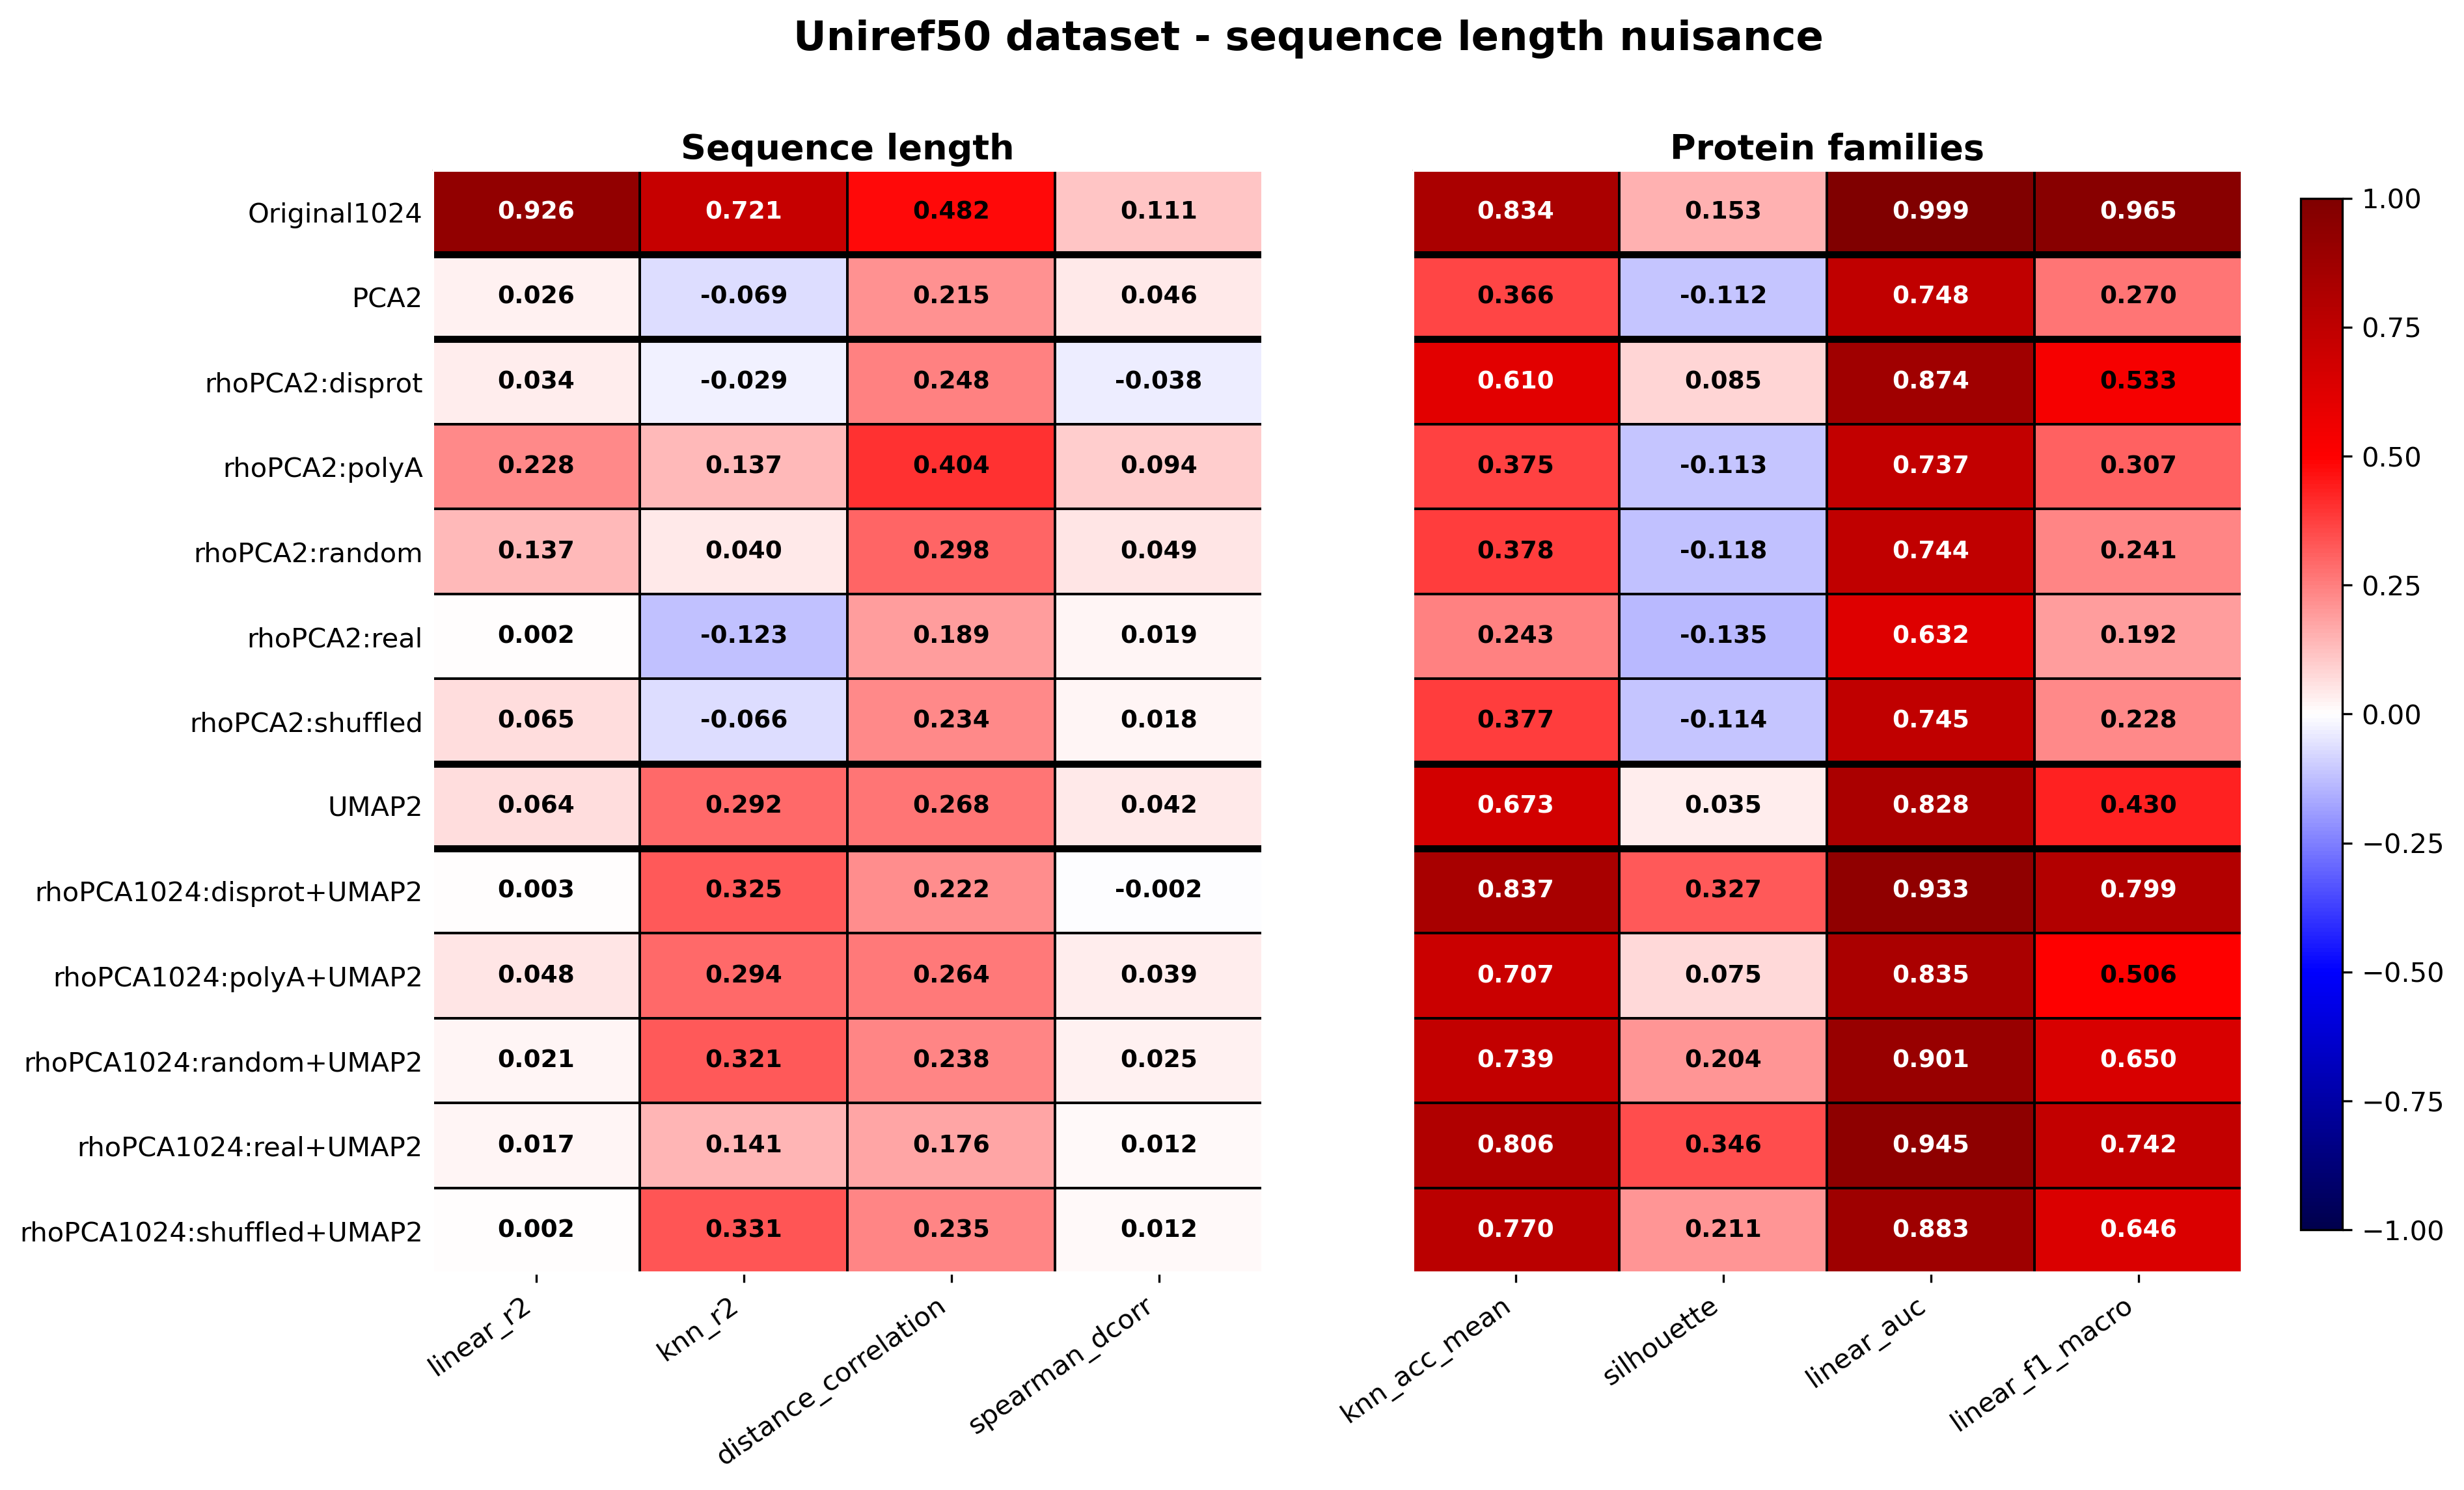

Summary: protspace_results/length/eval/prott5/summary.tsv
Rows plotted: 27 / 59
Panels: Supervised: length, Supervised: protein_families


,space,type,robustness_runs,recall_mean,recall_mean_std,trust_mean,trust_mean_std,cont_mean,cont_mean_std,linear_r2:length,...,knn_acc_mean:protein_families,knn_acc_mean_std:protein_families,silhouette:protein_families,silhouette_std:protein_families,concordex:protein_families,concordex_std:protein_families,linear_auc:protein_families,linear_auc_std:protein_families,linear_f1_macro:protein_families,linear_f1_macro_std:protein_families
0,Original (1024),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9257,...,0.8337,NaN,0.1529,NaN,5.6623,NaN,0.9989,NaN,0.9648,NaN
1,PCA10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5103,...,0.7739,NaN,0.1200,NaN,5.2566,NaN,0.9759,NaN,0.8394,NaN
2,PCA2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0257,...,0.3656,NaN,-0.1124,NaN,2.0621,NaN,0.7476,NaN,0.2702,NaN
3,PCA2 - Full,unsupervised,1.0,0.0378,NaN,0.9527,NaN,0.9560,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PCA50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7808,...,0.8546,NaN,0.0946,NaN,5.6235,NaN,0.9942,NaN,0.9462,NaN
5,UMAP2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0639,...,0.6734,NaN,0.0345,NaN,4.7172,NaN,0.8282,NaN,0.4300,NaN
6,UMAP2 - Full,unsupervised,1.0,0.2491,NaN,0.9729,NaN,0.9784,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,rhoPCA1024:disprot+UMAP2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0030,...,0.8369,NaN,0.3271,NaN,6.3137,NaN,0.9326,NaN,0.7993,NaN
8,rhoPCA1024:disprot+UMAP2 - Full,unsupervised,1.0,0.2204,NaN,0.9677,NaN,0.9712,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,rhoPCA1024:polyA+UMAP2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0477,...,0.7068,NaN,0.0754,NaN,5.0219,NaN,0.8347,NaN,0.5064,NaN


In [159]:
# Example: one figure with unsupervised first, then one subplot per supervised label.
plot_protspace_summary(
    "protspace_results/length",
    include_tsne=False,
    row_filter="64",
    include_unsupervised=False,
    supervised_label_filter=None,
    include_concordex=False,
    show_std=True,
    save=False,
    title="Uniref50 dataset - sequence length nuisance",
    subplot_titles=["Sequence length", "Protein families"],
)